# **1. Perkenalan Dataset**


## Dataset yang Digunakan

Pada proyek ini digunakan dataset **Heart Disease Dataset** yang berasal dari UCI Machine Learning Repository dan tersedia juga dalam bentuk dataset Kaggle.

Dataset ini merupakan data medis pasien yang digunakan untuk memprediksi risiko penyakit jantung berdasarkan berbagai parameter klinis seperti usia, jenis kelamin, tekanan darah, kolesterol, detak jantung maksimum, dan indikator kesehatan lainnya.

Dataset ini terdiri dari beberapa fitur penting, antara lain:
- age: usia pasien
- sex: jenis kelamin
- cp: jenis nyeri dada
- trestbps: tekanan darah istirahat
- chol: kadar kolesterol
- fbs: gula darah puasa
- restecg: hasil elektrokardiografi
- thalach: detak jantung maksimum
- exang: angina akibat aktivitas
- oldpeak: depresi ST
- slope: kemiringan segmen ST
- ca: jumlah pembuluh darah utama
- thal: kondisi talasemia
- target: indikasi penyakit jantung

### Sumber Dataset:
- UCI Machine Learning Repository:  
https://archive.ics.uci.edu/dataset/45/heart+disease  

- Kaggle Dataset Mirror:  
https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
#Type your code here
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
#Type your code here
df = pd.read_csv("heartdisease_raw.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtyp

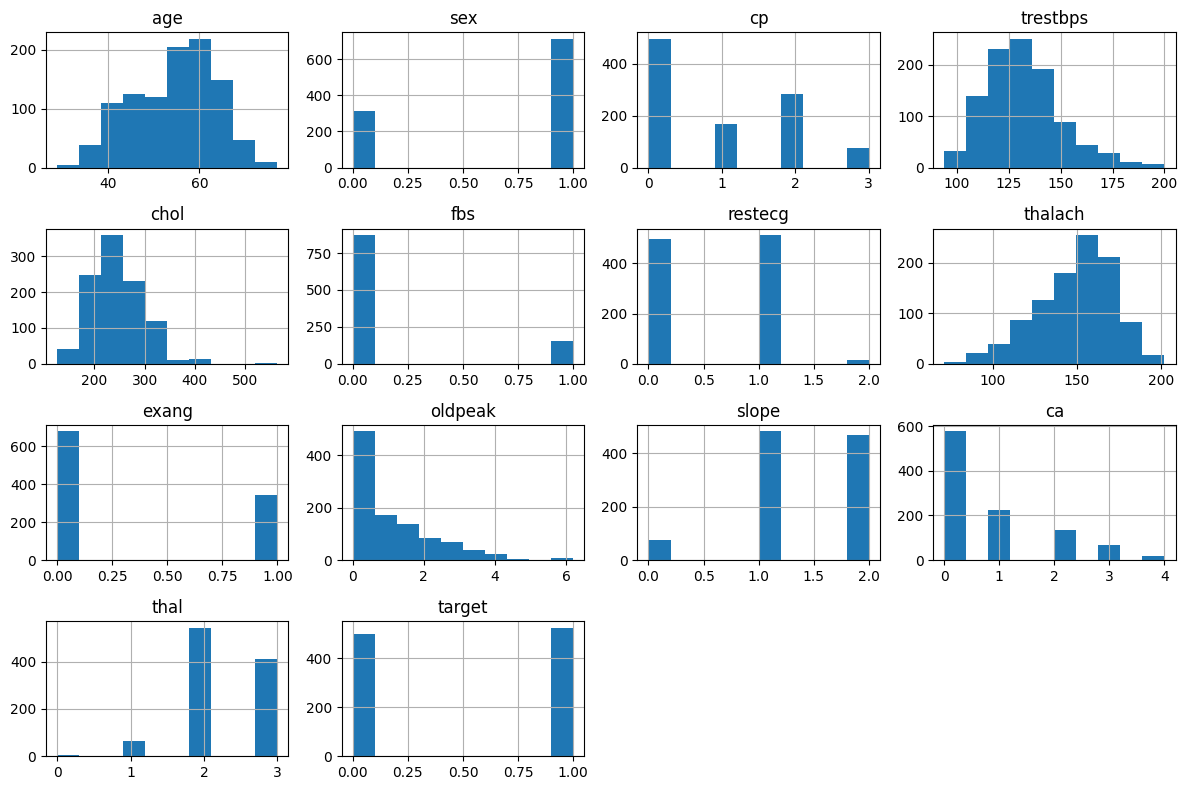

In [ ]:
#Type your code here
df.info()
df.describe()

print("Missing Values:")
print(df.isnull().sum())

print("\nJumlah Duplikat:")
print(df.duplicated().sum())

print("\nDistribusi Target:")
print(df["target"].value_counts())

df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
df = df.drop_duplicates()

X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

processed_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

processed_df["target"] = y.values

processed_df.to_csv(
    "heartdisease_preprocessed.csv",
    index=False
)